### Prepros

In [1]:
import ROOT
import pandas as pd

# Definir la ruta del archivo ROOT y el nombre del arbol
#DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0 (grande)
#DTDPGNtuple_12_4_2_Phase2Concentrator_Simulation_89
ruta_archivo_root = '../dtTuples/DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0.root'
nombre_arbol = 'dtNtupleProducer/DTTREE'

# Abrir el archivo ROOT
archivo = ROOT.TFile.Open(ruta_archivo_root)
if not archivo or archivo.IsZombie():
    raise FileNotFoundError(f"No se pudo abrir el archivo ROOT en {ruta_archivo_root}")
    
# Obtener el arbol
arbol = archivo.Get(nombre_arbol)
if not arbol:
    raise ValueError(f"No se encontro el arbol '{nombre_arbol}' en el archivo ROOT.")

# Obtener el numero de eventos en el arbol
numero_eventos = arbol.GetEntries()
print(f"El arbol tiene {numero_eventos} eventos.")

El arbol tiene 933000 eventos.


In [2]:
# Listas de ramas
ramas_event = ['event_eventNumber']
ramas_digis_numericas = ["digi_nDigis", "digi_wheel", "digi_sector", "digi_station", 
    "digi_superLayer", "digi_layer", "digi_wire", "digi_time"]
ramas_seg_numericas = [
    "seg_nSegments", "seg_wheel", "seg_sector", "seg_station", "seg_hasPhi", 
    "seg_hasZed", "seg_posLoc_x", "seg_posLoc_y", "seg_posLoc_z", 
    "seg_dirLoc_x", "seg_dirLoc_y", "seg_dirLoc_z", "seg_posLoc_x_SL1", 
    "seg_posLoc_x_SL3", "seg_posLoc_x_midPlane", "seg_posGlb_phi", 
    "seg_posGlb_eta", "seg_dirGlb_phi", "seg_dirGlb_eta", "seg_phi_t0", 
    "seg_phi_vDrift", "seg_phi_normChi2", "seg_phi_nHits", 
    "seg_z_normChi2", "seg_z_nHits"
]
ramas_seg_arrays = [
    'seg_phiHits_pos', 'seg_phiHits_posCh', 'seg_phiHits_posErr', 
    'seg_phiHits_side', 'seg_phiHits_wire', 'seg_phiHits_wirePos', 
    'seg_phiHits_layer', 'seg_phiHits_superLayer', 'seg_phiHits_time', 
    'seg_phiHits_timeCali'
]

ramas_a_extraer = ramas_event + ramas_digis_numericas + ramas_seg_numericas + ramas_seg_arrays

In [3]:
# Inicializar diccionario para almacenar los datos
data = {rama: [] for rama in ramas_a_extraer}

# Obtener el numero de eventos en el arbol
numero_eventos = arbol.GetEntries()
print(f"El arbol tiene {numero_eventos} eventos.")

El arbol tiene 933000 eventos.


In [4]:
from collections import defaultdict
import time

data = defaultdict(list)

max_eventos = 10000

start_total = time.time()

# Iterar sobre las entradas del arbol
for i, evento in enumerate(arbol):
    start_event = time.time()
    if i >= max_eventos:
        break  # Detener el bucle cuando se alcanzan max_eventos
    for rama in ramas_a_extraer:
        valor = getattr(evento, rama, None)
        
        if valor is None:
            data[rama].append(None)
            continue

        # Optimizacion: manejar TClonesArray
        if hasattr(valor, 'GetEntriesFast'):
            n_entries = valor.GetEntriesFast()  # Guardar numero de entradas
            valores = [
                [x for x in valor.At(i)] if hasattr(valor.At(i), '__len__') else valor.At(i)
                for i in range(n_entries)
            ]
            data[rama].append(valores)
        elif isinstance(valor, (ROOT.TVectorF, ROOT.TVectorD)):
            # Optimizacion: convertir directamente a lista
            data[rama].append(list(valor))
        elif isinstance(valor, (int, float)):
            # Escalar simple
            data[rama].append(valor)
        else:
            try:
                # Intentar convertir a lista si es iterable
                data[rama].append(list(valor))
            except TypeError:
                data[rama].append(valor)
    end_event = time.time()
    if i%1000==0:
        print(f"Evento {i+1}: {end_event - start_event:.2f} segundos")

end_total = time.time()
print(f"Tiempo total: {end_total - start_total:.2f} segundos")
# Cerrar el archivo ROOT
archivo.Close()


Evento 1: 0.07 segundos
Evento 1001: 0.00 segundos
Evento 2001: 0.00 segundos
Evento 3001: 0.00 segundos
Evento 4001: 0.00 segundos
Evento 5001: 0.00 segundos
Evento 6001: 0.00 segundos
Evento 7001: 0.00 segundos
Evento 8001: 0.00 segundos
Evento 9001: 0.00 segundos
Tiempo total: 9.63 segundos


In [5]:
# Verificar que todas las ramas tienen la misma longitud
longitudes = {rama: len(val) for rama, val in data.items()}
print("Longitud de cada rama:")

for rama, longitud in longitudes.items():
    print(f"{rama}: {longitud}")

# Convertir a DataFrame
try:
    df = pd.DataFrame(data)
except ValueError as e:
    print("Error al crear el DataFrame:", e)
    for rama, longitud in longitudes.items():
        print(f"{rama}: {longitud}")
    raise

# Mostrar una vista previa del DataFrame
print("\nVista previa del DataFrame:")
df.head()

# Contar los hits en las ramas tipo array
for rama in ramas_seg_arrays:
    if rama in df.columns:
        df[f'{rama}_count'] = df[rama].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Mostrar conteos
for rama in ramas_seg_arrays:
    if f'{rama}_count' in df.columns:
        print(f"\nNumero de hits por evento en '{rama}':")
        print(df[f'{rama}_count'].head())

# Guardar el DataFrame en un archivo CSV
df.to_csv('data.csv', index=False)
print('Data saved in data.csv')

#Ahora ya puedes trabajar con el df para generar las entradas/verdades de tu modelo de ML
#Siempre asegurate de preprocesar el df, rellenar los NaNs, normalizar los datos, etc.

#Recuerda que deberiamos filtrar los digis pertenecientes a la SL2 (no trabajamos en esa dimension)
#Lo mismo para los segmentos que no tienen hits en phi (son segmentos de la SL2 y tambien tenemos que cargarnoslos)
# Suerte! :)

Longitud de cada rama:
event_eventNumber: 10000
digi_nDigis: 10000
digi_wheel: 10000
digi_sector: 10000
digi_station: 10000
digi_superLayer: 10000
digi_layer: 10000
digi_wire: 10000
digi_time: 10000
seg_nSegments: 10000
seg_wheel: 10000
seg_sector: 10000
seg_station: 10000
seg_hasPhi: 10000
seg_hasZed: 10000
seg_posLoc_x: 10000
seg_posLoc_y: 10000
seg_posLoc_z: 10000
seg_dirLoc_x: 10000
seg_dirLoc_y: 10000
seg_dirLoc_z: 10000
seg_posLoc_x_SL1: 10000
seg_posLoc_x_SL3: 10000
seg_posLoc_x_midPlane: 10000
seg_posGlb_phi: 10000
seg_posGlb_eta: 10000
seg_dirGlb_phi: 10000
seg_dirGlb_eta: 10000
seg_phi_t0: 10000
seg_phi_vDrift: 10000
seg_phi_normChi2: 10000
seg_phi_nHits: 10000
seg_z_normChi2: 10000
seg_z_nHits: 10000
seg_phiHits_pos: 10000
seg_phiHits_posCh: 10000
seg_phiHits_posErr: 10000
seg_phiHits_side: 10000
seg_phiHits_wire: 10000
seg_phiHits_wirePos: 10000
seg_phiHits_layer: 10000
seg_phiHits_superLayer: 10000
seg_phiHits_time: 10000
seg_phiHits_timeCali: 10000

Vista previa del DataF

In [6]:
from newGeo.dtGeometry import *
from itertools import chain
import logging

geometry_xml_path = "newGeo/DTGeometry.xml"

# Parse DT Geometry XML
print("\nParsing DT Geometry XML...")
df_geometry = parse_dtgeometry_xml(geometry_xml_path)

def create_wire_position_mapping(df_geometry):
    mapping = {}
    for idx, row in df_geometry.iterrows():
        chamber_rawId = row['Chamber_rawId']
        superLayerNumber = row['SuperLayerNumber']
        layerNumber = row['LayerNumber']
        channels_total = row['Channels_total']
        wireFirst = row['WirePositions_FirstWire']
        wireLast = row['WirePositions_LastWire']
        # Create Wire object to get positions
        wire_obj = Wire(wireFirst, wireLast, channels_total, row['Layer_Local_z'])
        # Map wire numbers to positions
        for wire_idx, x_pos in enumerate(wire_obj.positions):
            wire_number = wire_idx + 1  # Assuming wire numbers start from 1
            key = (chamber_rawId, superLayerNumber, layerNumber, wire_number)
            mapping[key] = x_pos
    return mapping

def explode_dataframe(df, list_columns):
    """Explota columnas con listas en filas separadas."""
    # Repetir indices segun la longitud de las listas
    lengths = df[list_columns[0]].apply(len)
    idx = df.index.repeat(lengths)

    # Explotar las columnas de listas
    exploded_data = {col: list(chain.from_iterable(df[col])) for col in list_columns}

    # Agregar las columnas que no son listas
    exploded_df = pd.DataFrame(exploded_data, index=idx)
    non_list_columns = df.columns.difference(list_columns)
    for col in non_list_columns:
        exploded_df[col] = df[col].repeat(lengths)

    return exploded_df.reset_index(drop=True)

def add_chamber_rawId_to_digis(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['digi_wheel'], row['digi_station'], row['digi_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['digi_chamber_rawId'] = chamber_rawIds
    return df

def map_digi_wires_to_positions(df, wire_position_mapping):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    for idx, row in df.iterrows():
        key = (row['digi_chamber_rawId'], row['digi_superLayer'], row['digi_layer'], row['digi_wire'])
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        x_positions.append(x_pos)
    df['digi_x_pos'] = x_positions
    return df

def reconstruct_dataframe(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    df_flattened["original_index"] = df_original.index.repeat(
        df_original[list_columns[0]].apply(len)
    )

    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

wire_position_mapping = create_wire_position_mapping(df_geometry)

# Columnas con valores en listas
list_columns = ['digi_wheel', 'digi_sector', 'digi_station', 'digi_superLayer', 'digi_layer', 'digi_wire']

# Explotar el DataFrame para trabajar con cada digi individualmente
df_flattened = explode_dataframe(df, list_columns)

# Agregar la columna chamber_rawId
df_flattened = add_chamber_rawId_to_digis(df_flattened)

# Calcular las posiciones de los wires
df_flattened = map_digi_wires_to_positions(df_flattened, wire_position_mapping)

# Reconstruir el DataFrame original con la nueva columna
df = reconstruct_dataframe(df, df_flattened, list_columns, ['digi_x_pos'])

# Reordenar columnas para que digi_x_pos aparezca despues de digi_wire
columns = df.columns.tolist()
digi_wire_index = columns.index('digi_wire')
columns.insert(digi_wire_index + 1, columns.pop(columns.index('digi_x_pos')))
df = df[columns]

# Mostrar el DataFrame final 
#print(df.head())


Parsing DT Geometry XML...


In [7]:
# Ramas relacionadas con 'digis'
ramas_digis = [
    "event_eventNumber",
    "digi_nDigis", "digi_wheel", "digi_sector", "digi_station", 
    "digi_superLayer", "digi_layer", "digi_wire", "digi_time"
]

# Ramas relacionadas con 'segments' (seg)
ramas_segments = [
    "event_eventNumber",
    "seg_nSegments",
    "seg_wheel",
    "seg_sector",
    "seg_station",
    "seg_hasPhi",
    "seg_hasZed",
    "seg_posLoc_x",
    "seg_posLoc_y",
    "seg_posLoc_z",
    "seg_dirLoc_x",
    "seg_dirLoc_y",
    "seg_dirLoc_z",
    "seg_posLoc_x_SL1",
    "seg_posLoc_x_SL3",
    "seg_posLoc_x_midPlane",
    "seg_posGlb_phi",
    "seg_posGlb_eta",
    "seg_dirGlb_phi",
    "seg_dirGlb_eta",
    "seg_phi_t0",
    "seg_phi_vDrift",
    "seg_phi_normChi2",
    "seg_phi_nHits",
    "seg_z_normChi2",
    "seg_z_nHits",
    "seg_phiHits_wire",
    "seg_phiHits_layer",
    "seg_phiHits_superLayer"
]

# Combinar todas las ramas a extraer
ramas_a_extraer = ramas_digis + ramas_segments

In [8]:
# Extraer las ramas relacionadas con 'digis' en un DataFrame de pandas
df_digis = df[ramas_digis]

# Extraer las ramas relacionadas con 'segments' en otro DataFrame de pandas
df_segments = df[ramas_segments]

In [9]:
# Funcion para convertir Awkward Arrays a listas de Python
def convertir_a_lista(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    return [x]  # En caso de que sea un valor escalar, lo convertimos en lista

# Aplicar la conversion a todas las columnas de 'digis' que son listas ( excepto 'event_eventNumber' )  

for col in ramas_digis:
    df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)

for col in ramas_segments:
    df_segments.loc[:, col] = df_segments[col].apply(convertir_a_lista)

/tmp/ipykernel_4351/200737374.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([27005]) list([27004]) list([27001]) ... list([96999]) list([96996])
 list([96997])]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)
/tmp/ipykernel_4351/200737374.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([23]) list([131]) list([82]) ... list([33]) list([53]) list([92])]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)
/tmp/ipykernel_4351/200737374.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([27005]) list([27004]) list([27001]) ... list([96999]) list([

### digis

In [10]:
# Definir las columnas relacionadas con 'digis' que seran aplanadas
columns_to_explode_digis = ['digi_superLayer', 'digi_layer', 'digi_wire', 'digi_time', 'digi_wheel', 'digi_sector', 'digi_station']

# Funcion para verificar si todas las listas tienen la misma longitud en una fila
def verificar_longitudes(row, cols):
    lengths = [len(row[col]) for col in cols]
    return len(set(lengths)) == 1  # True si todas las longitudes son iguales

# Aplicar la funcion a cada fila
# Asignar la columna 'same_length' usando .loc
df_digis['same_length'] = df_digis.apply(lambda row: verificar_longitudes(row, columns_to_explode_digis), axis=1)

# Verificar cuantas filas cumplen la condicion
print("Numero de filas con listas de la misma longitud en 'digis':")
print(df_digis['same_length'].value_counts())

# Filtrar solo las filas que cumplen la condicion
df_digis = df_digis[df_digis['same_length']]

# Eliminar la columna auxiliar
df_digis = df_digis.drop(columns=['same_length'])


Numero de filas con listas de la misma longitud en 'digis':
same_length
True    10000
Name: count, dtype: int64


/tmp/ipykernel_4351/1437617869.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_digis['same_length'] = df_digis.apply(lambda row: verificar_longitudes(row, columns_to_explode_digis), axis=1)


In [11]:
# ahora vamos a aplanar las columnas de 'digis' que contienen listas
columns_to_explode_digis = [
    'digi_superLayer', 'digi_layer', 'digi_wire', 
    'digi_time', 'digi_wheel', 'digi_sector', 'digi_station'
]

df_digis_exploded = df_digis.explode(columns_to_explode_digis)

# Renombrar las columnas a nombres mas cortos
df_digis_exploded = df_digis_exploded.rename(columns={
    "event_eventNumber": "eventNumber",
    "digi_superLayer": "superLayer",
    "digi_layer": "layer",
    "digi_wire": "wire",
    "digi_time": "time",
    "digi_wheel": "wheel",
    "digi_sector": "sector",
    "digi_station": "station"
})

# Convertir 'event_eventNumber' a entero, ya que antes era una lista
df_digis_exploded['eventNumber'] = df_digis_exploded['eventNumber'].apply(lambda x: x if isinstance(x, (int, str)) else x[0])

# Eliminar la columna 'digi_nDigis', no es necesaria
df_digis_exploded = df_digis_exploded.drop(columns=['digi_nDigis'])

# ELiminamos los digis de la superLayer 2, ya que no son necesarios y pueden influir en los resultados
df_digis_exploded = df_digis_exploded[df_digis_exploded['superLayer'] != 2]
df_digis_exploded = df_digis_exploded[df_digis_exploded['superLayer'] == 1]

In [12]:
# Ahora vamos a agrupar los digis por evento y estacion
df_digis_grouped = df_digis_exploded.groupby(
    ['eventNumber', 'wheel', 'sector', 'station']
).agg({
    'superLayer': list,
    'layer': list,
    'wire': list,
    'time': list
}).reset_index()

df_digis_grouped['n_digis'] = df_digis_grouped['wire'].apply(len)

# Mostrar una vista previa despues de aplanar
tamaño_bytes = df_digis_grouped.memory_usage(deep=True).sum()
print(f"Tamaño del DataFrame en bytes: {tamaño_bytes}")
#df_digis_grouped.head()


Tamaño del DataFrame en bytes: 28924116


In [13]:
#agrupar digis para hacer los grafos
df_digis_nodos = df_digis_exploded.groupby(
    ['eventNumber', 'wheel', 'sector', 'station','superLayer']
).agg({
    'wire': list,
    'layer': list,
    'time': list
}).reset_index()

### segments

In [14]:
# Se construyen ahora la verdades con la parte de segments
# En concreto nos interesan las columnas seg_phiHits_wire y seg_phiHits_superlayer
# Creamos los grafos de la misma manera, primero aplanamos los datos

# Eliminar columnas de segmentos con las que no vamos a trabajar (todas menos 'event_eventNumber', 'seg_wheel', 'seg_sector', 'seg_station')

columnas_a_eliminar = [col for col in df_segments.columns if col not in ['event_eventNumber', 'seg_wheel', 'seg_sector', 'seg_station',"seg_phiHits_wire","seg_phiHits_layer","seg_phiHits_superLayer"]]

df_segments_filtered = df_segments.drop(columns=columnas_a_eliminar)

# Nos aseguramos de que 'event_eventNumber' sea un escalar, ya que antes convertimos todas las columnas a listas
df_segments_filtered['event_eventNumber'] = df_segments['event_eventNumber'].str[0]

# ahora vamos a aplanar las columnas de 'segments' que contienen listas
columns_to_explode_segments = [
    "seg_phiHits_superLayer", "seg_phiHits_layer", "seg_phiHits_wire", 
    'seg_wheel', 'seg_sector', 'seg_station'
]

df_segments_exploded = df_segments_filtered.explode(columns_to_explode_segments)

# Renombrar las columnas a nombres mas cortos
df_segments_exploded = df_segments_exploded.rename(columns={
    "event_eventNumber": "eventNumber",
    "seg_phiHits_superLayer": "superLayer",
    "seg_phiHits_layer": "layer",
    "seg_phiHits_wire": "wire",
    'seg_wheel': "wheel",
    'seg_sector': "sector",
    'seg_station': "station"
})

# Nos aseguramos de que 'event_eventNumber' sea un escalar, ya que antes convertimos todas las columnas a listas
df_segments_exploded['event_eventNumber'] = df_segments['event_eventNumber'].str[0]

df_segments_exploded.head()

,eventNumber,wheel,sector,station,wire,layer,superLayer,event_eventNumber
0,27005,2,1,1,"[27.0, 28.0, 26.0, 25.0, 26.0]","[3.0, 4.0, 2.0, 3.0, 4.0]","[1.0, 1.0, 3.0, 3.0, 3.0]",27005
0,27005,2,8,1,"[30.0, 31.0, 30.0, 30.0]","[1.0, 2.0, 3.0, 4.0]","[1.0, 1.0, 1.0, 1.0]",27005
1,27004,2,2,1,"[2.0, 1.0, 2.0]","[2.0, 3.0, 4.0]","[1.0, 1.0, 1.0]",27004
1,27004,-2,3,1,"[4.0, 5.0, 5.0, 5.0, 6.0]","[3.0, 1.0, 2.0, 3.0, 4.0]","[1.0, 3.0, 3.0, 3.0, 3.0]",27004
1,27004,-2,3,1,"[4.0, 5.0, 5.0, 5.0, 6.0]","[3.0, 1.0, 2.0, 3.0, 4.0]","[1.0, 3.0, 3.0, 3.0, 3.0]",27004


In [15]:
# hay que eliminar las filas que tienen listas vacias en wire, layer y superlayer puesto que estas pertenecen a la superlayer 2
# Identificar y eliminar filas donde col2 (u otra columna) tiene listas vacias
columnas_a_revisar = ["wire", 'layer', 'superLayer']  # Lista de columnas que queremos revisar
df_segments_exploded_limpio = df_segments_exploded[~df_segments_exploded[columnas_a_revisar]
    .apply(lambda col: col.apply(lambda x: isinstance(x, list) and len(x) == 0))
    .any(axis=1)
]

# convertir los numeros de una lista a enteros
def convertir_a_enteros(lista):
    return [int(x) if isinstance(x, (float, int)) else x for x in lista]

# Eliminar filas con NaNs
df_segments_exploded_limpio = df_segments_exploded_limpio.dropna()

# Aplicar la conversion solo a las columnas que contienen listas
df_segments_exploded_limpio.loc[:, "wire"] = df_segments_exploded_limpio["wire"].apply(convertir_a_enteros)
df_segments_exploded_limpio.loc[:, "layer"] = df_segments_exploded_limpio["layer"].apply(convertir_a_enteros)
df_segments_exploded_limpio.loc[:, "superLayer"] = df_segments_exploded_limpio["superLayer"].apply(convertir_a_enteros)

#volvemos a explotar
df_segments_exploded_2 = df_segments_exploded_limpio.explode(columnas_a_revisar)

# Ahora vamos a agrupar los digis por evento y estacion
df_segments_nodos = df_segments_exploded_2.groupby(
    ['eventNumber', 'wheel', 'sector', 'station', 'superLayer']
).agg({
    'layer': list,
    'wire': list,
}).reset_index()


df_segments_nodos = df_segments_nodos[df_segments_nodos['superLayer'] == 1]
df_segments_nodos.head()

,eventNumber,wheel,sector,station,superLayer,layer,wire
0,27001,0,2,1,1,"[1, 3, 4]","[29, 30, 30]"
2,27001,0,2,2,1,"[1, 3, 4]","[26, 27, 27]"
4,27001,0,2,3,1,"[1, 3]","[46, 47]"
6,27001,0,2,4,1,"[1, 2, 3, 4]","[34, 35, 34, 35]"
8,27001,2,2,1,1,"[1, 2, 3, 4]","[43, 44, 43, 43]"


### grafos

In [16]:
from itertools import zip_longest

df1 = df_digis_nodos
df2 = df_segments_nodos

# Columnas a usar para la comparacion de correspondencia (excluyendo 'wire' y 'layer')
comparison_columns = ["eventNumber", "wheel", "sector", "station", "superLayer"]

# Unir los DataFrames
merged_df = pd.merge(df1, df2, on=comparison_columns, suffixes=('_df1', '_df2'))

# Comparar listas con manejo de longitudes distintas
def compare_lists(list1, list2):
    return [x == y if x is not None and y is not None else False for x, y in zip_longest(list1, list2)]

# Aplicar la comparacion de listas a las columnas 'wire' y 'layer'
merged_df['wire_comparison'] = merged_df.apply(lambda row: compare_lists(row['wire_df1'], row['wire_df2']), axis=1)
merged_df['layer_comparison'] = merged_df.apply(lambda row: compare_lists(row['layer_df1'], row['layer_df2']), axis=1)

# Seleccionar solo las columnas de interes
df_verdad = merged_df[['wire_comparison', 'layer_comparison']]

df_digis_nodos = merged_df[['eventNumber', 'wheel', 'sector', 'station', 'superLayer', 'wire_df1', 'layer_df1']]

df_segments_nodos = merged_df[['eventNumber', 'wheel', 'sector', 'station', 'superLayer', 'wire_df2', 'layer_df2']]

#print(df_verdad)

In [17]:
import torch
import itertools
from torch_geometric.data import Data

def nodos_triangulares(row):
    # Definir los nodos del triangulo (9 nodos)
    digi_layer, digi_wire = row['layer_df1'][0], row['wire_df1'][0]
    nodos_triang = []

    def add_nodo(w,l):
        nodos_triang.append((w, l))
    
    add_nodo(digi_wire, digi_layer)

    if digi_layer == 1:
        #layer2
        add_nodo(digi_wire, digi_layer+1)
        add_nodo(digi_wire+1, digi_layer+1)

        #layer3
        add_nodo(digi_wire-1, digi_layer+2)
        add_nodo(digi_wire, digi_layer+2)
        add_nodo(digi_wire+1, digi_layer+2)

        #layer4
        add_nodo(digi_wire-2, digi_layer+3)
        add_nodo(digi_wire-1,   digi_layer+3)
        add_nodo(digi_wire, digi_layer+3)
        add_nodo(digi_wire+1, digi_layer+3) 

    elif digi_layer == 2:
        #layer3
        add_nodo(digi_wire, digi_layer+1)
        add_nodo(digi_wire+1, digi_layer+1)

        #layer4
        add_nodo(digi_wire-2, digi_layer+2)
        add_nodo(digi_wire-1, digi_layer+2)
        add_nodo(digi_wire, digi_layer+2)

    elif digi_layer == 3:
        #layer4
        add_nodo(digi_wire-1, digi_layer+1)
        add_nodo(digi_wire, digi_layer+1)

    return nodos_triang


/home/blanca_belmonte/miniconda3/envs/jupyter_ml_env/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/blanca_belmonte/miniconda3/envs/jupyter_ml_env/lib/python3.11/site-packages/torch_scatter/_version_cpu.so: undefined symbol: _ZN3c106detail14torchCheckFailEPKcS2_jRKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/blanca_belmonte/miniconda3/envs/jupyter_ml_env/lib/python3.11/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/blanca_belmonte/miniconda3/envs/jupyter_ml_env/lib/python3.11/site-packages/torch_cluster/_version_cpu.so: undefined symbol: _ZN3c106detail14torchCheckFailEPKcS2_jRKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE
  warnings.warn(f"An issue occurred while importing 'torch-clus

In [18]:
import torch
import itertools
from torch_geometric.data import Data

def crear_grafo(row, row_verdad):  
    # indice de nodos basado en nodos_triang
    nodos_triang = nodos_triangulares(row)
    nodo_indices = {nodo: idx for idx, nodo in enumerate(nodos_triang)}
    
    # Datos del dataset
    wires = row['wire_df1']
    layers = row['layer_df1']
    nodos_digis = [(wires[i], layers[i]) for i in range(len(wires))]

    # Se genera las aristas usando las restricciones en nodos_digis pero mapeados en los nodos_triang
    edge_index = []
    primeros_vecinos = set()
    segundos_vecinos = set()
    terceros_vecinos = set()

    for i, j in itertools.combinations(range(len(nodos_digis)), 2):
        wire_i, layer_i = nodos_digis[i]
        wire_j, layer_j = nodos_digis[j]
        if abs(layer_i - layer_j) == 1 and abs(wire_i - wire_j) <= 1:
            # Mapear los nodos digis a nodos_triang
            if nodos_digis[i] in nodo_indices and nodos_digis[j] in nodo_indices:
                idx_i = nodo_indices[nodos_digis[i]]
                idx_j = nodo_indices[nodos_digis[j]]
                edge_index.append((idx_i, idx_j))
                primeros_vecinos.add(nodos_digis[i])

        elif nodos_digis[i] not in primeros_vecinos and layer_i != 4 and layer_i != 3:
            if abs(layer_i - layer_j) == 2 and abs(wire_i- wire_j) <= 2:
                if nodos_digis[i] in nodo_indices and nodos_digis[j] in nodo_indices:
                    idx_i = nodo_indices[nodos_digis[i]]
                    idx_j = nodo_indices[nodos_digis[j]]
                    edge_index.append((idx_i, idx_j))
                    segundos_vecinos.add(nodos_digis[i])

            elif nodos_digis[i] not in segundos_vecinos:
                if abs(layer_i - layer_j) == 3 and abs(wire_i- wire_j) <= 3:
                    if nodos_digis[i] in nodo_indices and nodos_digis[j] in nodo_indices:
                        idx_i = nodo_indices[nodos_digis[i]]
                        idx_j = nodo_indices[nodos_digis[j]]
                        edge_index.append((idx_i, idx_j))
        
    # grafo de verdad
    wires_verdad = row_verdad['wire_df2']
    layers_verdad = row_verdad['layer_df2']
    nodos_verdad = [(wires_verdad[i], layers_verdad[i]) for i in range(len(wires_verdad))]

    # etiquetas de los nodos
    node_labels = []
    for nodo in nodos_triang:
        if nodo in nodos_verdad:
            node_labels.append(1)  # esta en el grafo de verdad
        else:
            node_labels.append(0)  # no esta en el grafo de verdad

    # Convertir datos a tensores de PyTorch
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x = torch.tensor([[wire, layer] for wire, layer in nodos_triang], dtype=torch.float)
    node_labels = torch.tensor(node_labels, dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=None, y=node_labels)

In [19]:
# Ejemplo
grafo_verdad = crear_grafo(df_digis_nodos.iloc[0], df_segments_nodos.iloc[0])

# Imprimir el grafo resultante
print(grafo_verdad)

#  aristas del grafo
edge_index = grafo_verdad.edge_index
aristas = edge_index
print('nodos:', grafo_verdad.x)
print("Aristas: \n", aristas)  

# etiquetas de la verdad
print('Verdad', grafo_verdad.y)

Data(x=[10, 2], edge_index=[2, 3], y=[10])
nodos: tensor([[29.,  1.],
        [29.,  2.],
        [30.,  2.],
        [28.,  3.],
        [29.,  3.],
        [30.,  3.],
        [27.,  4.],
        [28.,  4.],
        [29.,  4.],
        [30.,  4.]])
Aristas: 
 tensor([[0, 2, 5],
        [2, 5, 9]])
Verdad tensor([1, 0, 0, 0, 0, 1, 0, 0, 0, 1])


Explicacion de lo que son los Data

1.  x=[8, 2]
Esto representa las caracteristicas de los nodos del grafo. x es un tensor de dimensiones [8, 2]:

    - 8: Numero de nodos en el grafo.
    - 2: Numero de caracteristicas asociadas a cada nodo.

2. edge_index=[2, 7]
    Esto representa las aristas del grafo en forma de pares de indices de nodos. edge_index es un tensor de dimensiones [2, 7]:

    - 2: Cada columna de este tensor representa un par de nodos conectados (un "origen" y un "destino").
    - 7: Numero total de aristas en el grafo.

    Por ejemplo:
    
        edge_index =  [[0, 1, 2, 3, 4, 5, 6],  # Nodo origen de cada arista
                       [1, 2, 3, 4, 5, 6, 7]]  # Nodo destino de cada arista
              
    Esto significa que:

    - Hay una arista desde el nodo 0 al nodo 1.
    - Hay una arista desde el nodo 1 al nodo 2.

3. y=[8]
    Representa las etiquetas o targets del grafo. 'y' es un tensor de dimensiones [8]:

    8: Numero de nodos (igual al numero de filas en x), indicando que cada nodo tiene una etiqueta asociada.

    Por ejemplo:
        y = [1, 0, 1, 0, 0, 1, 1, 0]


### Dataset

In [20]:
#CREAR DATASET
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler

class GrafoDataset(Dataset):
    def __init__(self, data_rows, data_verdad, normalize=True):
        self.data_rows = data_rows
        self.data_verdad = data_verdad
        self.normalize = normalize  # Parametro que controla la normalizacion

    def __len__(self):
        return len(self.data_rows)

    def __getitem__(self, idx):
        row = self.data_rows[idx]
        row_verdad = self.data_verdad[idx]
        
        # Crear el grafo con posiciones
        data = crear_grafo(row, row_verdad)
        
        # Normalizar las posiciones
        if self.normalize:
            data.x = self.normalizar_posiciones(data.x)
        
        return data

    def normalizar_posiciones(self, x):
        # Normaliza las posiciones (x, y) de los nodos usando StandardScaler
        scaler = StandardScaler()
        posiciones = x.numpy()  # Convertir a numpy para usar el scaler
        posiciones_normalizadas = scaler.fit_transform(posiciones)  # Normalizar
        return torch.tensor(posiciones_normalizadas, dtype=torch.float)

# convertir a listas
df_digis_nodos_lista = df_digis_nodos.to_dict('records')
df_segments_nodos_lista = df_segments_nodos.to_dict('records')

# dataset
dataset = GrafoDataset(df_digis_nodos_lista, df_segments_nodos_lista)
print(f"Tamaño del dataset: {len(dataset)}")
ejemplo = dataset[0]  # Acceder al primer grafo
print(ejemplo) 

Tamaño del dataset: 37083
Data(x=[10, 2], edge_index=[2, 3], y=[10])


### Graph Neural Network

In [21]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Dropout

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_prob=0.5):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = Dropout(p=dropout_prob) # añado el dropotu para desfavorecer el sobreajuste

    def forward(self, x, edge_index):
        # convolucion + ReLU
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)  # Softmax logaritmico 

# Seleccionar GPU si no esta disponible pues CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}') 

Using device: cpu


### Train y tests dataset y dataloaders

In [22]:

from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# Dividir entre train y (validación + test)
train_dataset, temp_dataset = train_test_split(dataset, test_size=0.2, random_state=42)
validation_dataset, test_dataset = train_test_split(temp_dataset, test_size=0.5, random_state=42)

# Comprobamos el tamaño
print(f'Tamaño de los datasets: train = {len(train_dataset)},validation = {len(validation_dataset)}, test = {len(test_dataset)}' )

#creo que estos nans vienen de los key que no tienen una coordenada asociada
# De momento vamos a filtrar los Nans y ya veremos de donde vienen
def filtrar_nans(dataset):
    filtered_dataset = []
    dataset_con_nans =[]
    for i , data in enumerate(dataset):
        if torch.isnan(data.x).sum() == 0 and torch.isnan(data.y).sum() == 0:
            filtered_dataset.append(data)
        else:
            dataset_con_nans.append(data)
            #print(f'Datos con nans: indice = {i}')
            #print('dato = {data} \n nodos: {data.x} \n aristas: {data.y}')
    return filtered_dataset, dataset_con_nans

train_dataset, dataset_nans_train = filtrar_nans(train_dataset)
validation_dataset, dataset_nans_validation = filtrar_nans(validation_dataset)
test_dataset, dataset_nans_test = filtrar_nans(test_dataset)
# Comprobamos el tamaño
print(f'Tamaño de la parte del dataset con nans: train = {len(dataset_nans_train)}, validation = {len(dataset_nans_validation)}, test = {len(dataset_nans_test)}')
print(f'Tamaño de los datasets despues del fltrado: train = {len(train_dataset)}, validation = {len(validation_dataset)}, test = {len(test_dataset)}' )

# Creamos DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

Tamaño de los datasets: train = 29666,validation = 3708, test = 3709
Tamaño de la parte del dataset con nans: train = 0, validation = 0, test = 0
Tamaño de los datasets despues del fltrado: train = 29666, validation = 3708, test = 3709


In [ ]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

#divido el dataset
train_rows, test_rows, train_verdad, test_verdad = train_test_split(
    df_digis_nodos_lista, df_segments_nodos_lista, test_size=0.2, random_state=42
)

# Crear datasets
train_dataset = GrafoDataset(train_rows, train_verdad)
test_dataset = GrafoDataset(test_rows, test_verdad)
print(f'Longitudes antes del filtrado: train = {len(train_dataset)}, test = {len(test_dataset)}')

# Filtrar los grafos sin aristas (los grafos sin aristas me dan problemas el ejecutar el entrenamiento)
train_dataset = [data for data in train_dataset if data.edge_index.numel() > 0]
test_dataset = [data for data in test_dataset if data.edge_index.numel() > 0]
print(f'Longitudes despues del filtrado: {len(train_dataset)}, test = {len(test_dataset)}')

# Crear DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)


'''# Verifica los valores de edge_index
for i, data in enumerate(train_loader):
    if data.edge_index.numel() == 0:
        print('Numero de grafo:', i)
        print("No se generaron aristas.")'''


Longitudes antes del filtrado: train = 14899, test = 3725
Longitudes despues del filtrado: 14621, test = 3646


'# Verifica los valores de edge_index\nfor i, data in enumerate(train_loader):\n    if data.edge_index.numel() == 0:\n        print(\'Numero de grafo:\', i)\n        print("No se generaron aristas.")'

Epoch 1/30, Train Loss: 0.2728, Validation Loss: 0.2115
Epoch 2/30, Train Loss: 0.2040, Validation Loss: 0.1892
Epoch 3/30, Train Loss: 0.1895, Validation Loss: 0.1840
Epoch 4/30, Train Loss: 0.1865, Validation Loss: 0.1820
Epoch 5/30, Train Loss: 0.1854, Validation Loss: 0.1812
              precision    recall  f1-score   support

     Clase 0       0.97      0.93      0.95    189060
     Clase 1       0.88      0.94      0.91     99752

    accuracy                           0.94    288812
   macro avg       0.92      0.94      0.93    288812
weighted avg       0.94      0.94      0.94    288812



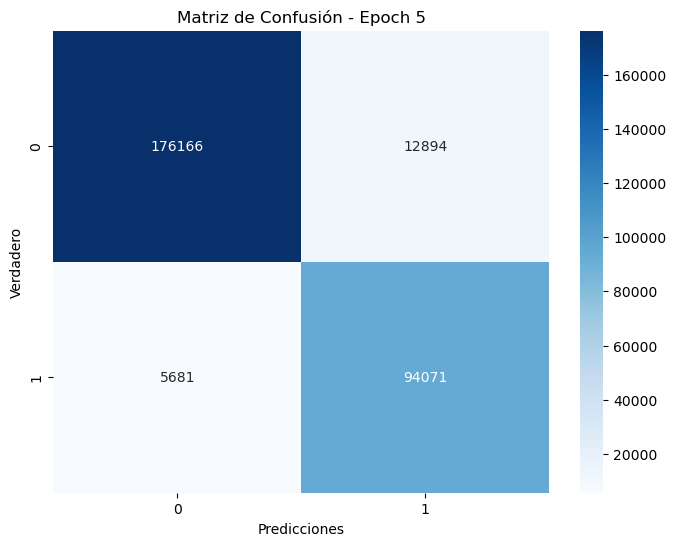

Epoch 6/30, Train Loss: 0.1847, Validation Loss: 0.1809
Epoch 7/30, Train Loss: 0.1839, Validation Loss: 0.1800
Epoch 8/30, Train Loss: 0.1833, Validation Loss: 0.1802
Epoch 9/30, Train Loss: 0.1828, Validation Loss: 0.1796
Epoch 10/30, Train Loss: 0.1827, Validation Loss: 0.1817
              precision    recall  f1-score   support

     Clase 0       0.98      0.93      0.95    189101
     Clase 1       0.88      0.96      0.92     99755

    accuracy                           0.94    288856
   macro avg       0.93      0.94      0.93    288856
weighted avg       0.94      0.94      0.94    288856



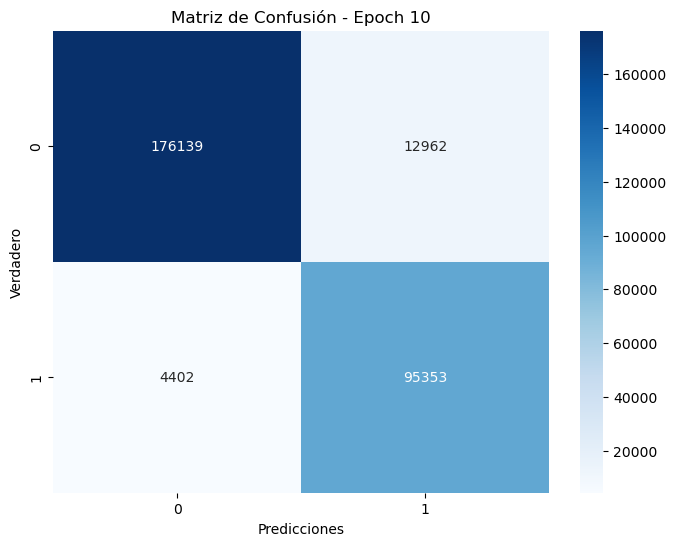

Epoch 11/30, Train Loss: 0.1821, Validation Loss: 0.1790
Epoch 12/30, Train Loss: 0.1810, Validation Loss: 0.1768
Epoch 13/30, Train Loss: 0.1782, Validation Loss: 0.1735
Epoch 14/30, Train Loss: 0.1752, Validation Loss: 0.1706
Epoch 15/30, Train Loss: 0.1697, Validation Loss: 0.1643
              precision    recall  f1-score   support

     Clase 0       0.99      0.93      0.96    189042
     Clase 1       0.88      0.99      0.93     99738

    accuracy                           0.95    288780
   macro avg       0.94      0.96      0.95    288780
weighted avg       0.95      0.95      0.95    288780



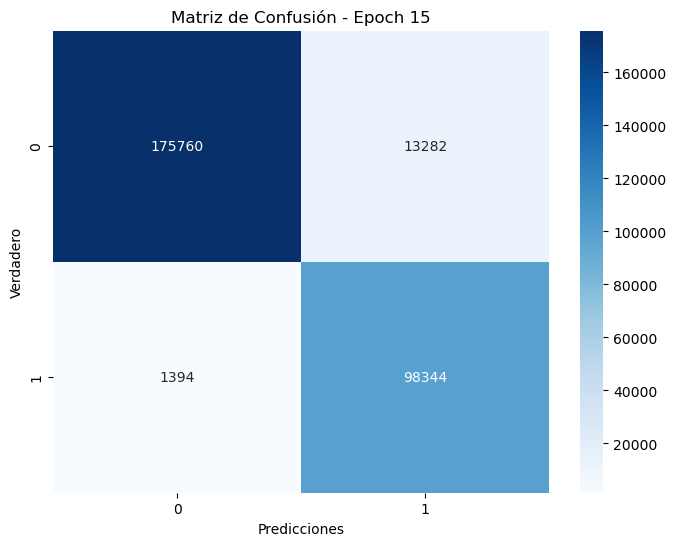

Epoch 16/30, Train Loss: 0.1653, Validation Loss: 0.1606
Epoch 17/30, Train Loss: 0.1625, Validation Loss: 0.1610
Epoch 18/30, Train Loss: 0.1609, Validation Loss: 0.1572
Epoch 19/30, Train Loss: 0.1588, Validation Loss: 0.1562
Epoch 20/30, Train Loss: 0.1580, Validation Loss: 0.1545
              precision    recall  f1-score   support

     Clase 0       1.00      0.93      0.96    189077
     Clase 1       0.88      0.99      0.93     99756

    accuracy                           0.95    288833
   macro avg       0.94      0.96      0.95    288833
weighted avg       0.96      0.95      0.95    288833



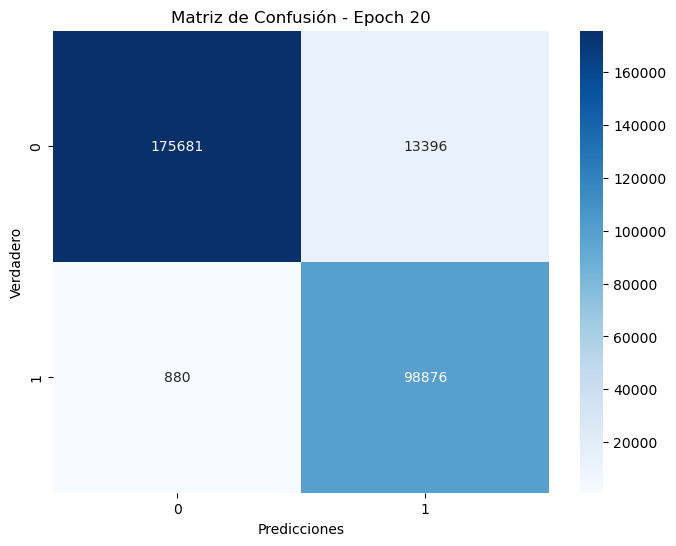

Epoch 21/30, Train Loss: 0.1568, Validation Loss: 0.1544
Epoch 22/30, Train Loss: 0.1561, Validation Loss: 0.1535
Epoch 23/30, Train Loss: 0.1557, Validation Loss: 0.1529
Epoch 24/30, Train Loss: 0.1555, Validation Loss: 0.1536
Epoch 25/30, Train Loss: 0.1550, Validation Loss: 0.1530
              precision    recall  f1-score   support

     Clase 0       1.00      0.93      0.96    189022
     Clase 1       0.88      0.99      0.93     99752

    accuracy                           0.95    288774
   macro avg       0.94      0.96      0.95    288774
weighted avg       0.96      0.95      0.95    288774



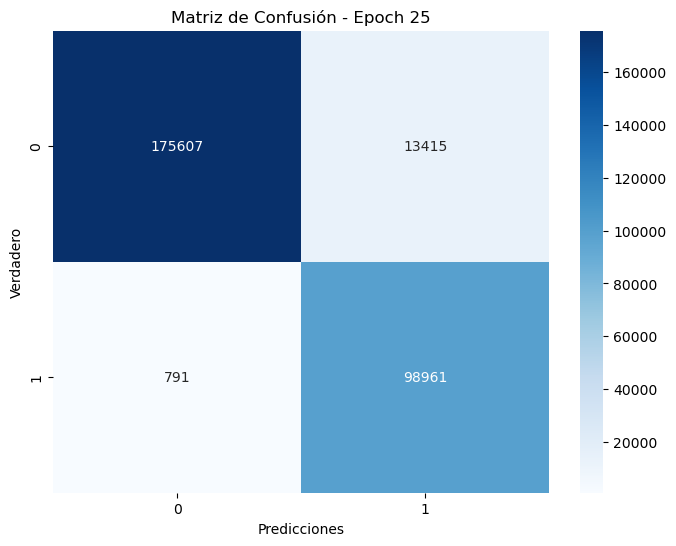

Epoch 26/30, Train Loss: 0.1550, Validation Loss: 0.1529
Epoch 27/30, Train Loss: 0.1549, Validation Loss: 0.1529
Epoch 28/30, Train Loss: 0.1549, Validation Loss: 0.1524
Epoch 29/30, Train Loss: 0.1550, Validation Loss: 0.1524
Epoch 30/30, Train Loss: 0.1548, Validation Loss: 0.1524
              precision    recall  f1-score   support

     Clase 0       1.00      0.93      0.96    189086
     Clase 1       0.88      0.99      0.93     99751

    accuracy                           0.95    288837
   macro avg       0.94      0.96      0.95    288837
weighted avg       0.96      0.95      0.95    288837



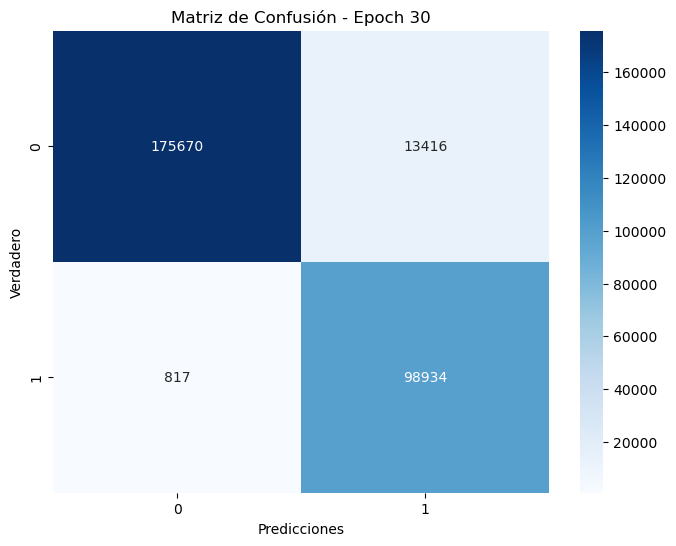

In [25]:
from torch.nn import CrossEntropyLoss
import torch
from sklearn.metrics import confusion_matrix, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Plotear la matriz de confusion
def plot_confusion(all_preds,all_labels,epoch):
    # Calcular la matriz de confusion y el F1-score
    cm = confusion_matrix(all_labels, all_preds)
    print(classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"]))

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.title(f'Matriz de Confusión - Epoch {epoch + 1}')
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.show()

# Parametros
input_dim = 2   # wire y layer
hidden_dim = 16
output_dim = 2  # Numero de clases (nodo verdad 1 o no 0)

# modelo, optimizador y perdida
model = GCN(input_dim, hidden_dim, output_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) #learning rate bajo para desfavorece el sobreajute 
#weight decay para implementar la regularizacion L2 que penaliza los pesos grandes

# por si hubiera q balancear las clases:
loss_fn = CrossEntropyLoss()
# epocas
epochs = 30

# para hacer las curvas de aprendizaje necesito almacenar las perdidas y precision
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# entrenamiento
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    all_preds = []  # almacenar las predicciones
    all_labels = []  # almacenar las etiquetas verdaderas

    for data in train_loader:
        # Verificar si el grafo tiene aristas
        if data.edge_index.numel() == 0:  
            continue 

        optimizer.zero_grad()
        # Forward pass
        out = model(data.x, data.edge_index)
        
        # Calcular perdida
        loss = loss_fn(out, data.y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Obtener predicciones y etiquetas verdaderas
        preds = out.argmax(dim=1).cpu().numpy()  # Predicciones
        labels = data.y.cpu().numpy()  # Etiquetas verdaderas

        all_preds.extend(preds) #concatenar
        all_labels.extend(labels)

    train_losses.append(epoch_loss/len(train_loader))
    train_accuracies.append(f1_score(all_labels, all_preds))

    #evaluar modelo
    model.eval()
    val_loss = 0
    all_preds_val = []
    all_labels_val = []
    with torch.no_grad():
        for data in validation_loader:
            if data.edge_index.numel() == 0:  
                continue 
            data = data.to(device)
            logits = model(data.x, data.edge_index)
            loss = loss_fn(logits, data.y)
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds_val.append(preds.cpu())
            all_labels_val.append(data.y.cpu())
    val_losses.append(val_loss/len(validation_loader))
    all_preds_val = torch.cat(all_preds_val).numpy()
    all_labels_val = torch.cat(all_labels_val).numpy()
    val_accuracies.append(f1_score(all_labels_val, all_preds_val))


    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(validation_loader):.4f}")
    if (epoch+1)%5 == 0:
        plot_confusion(all_preds, all_labels, epoch)

### Curvas de aprendizaje

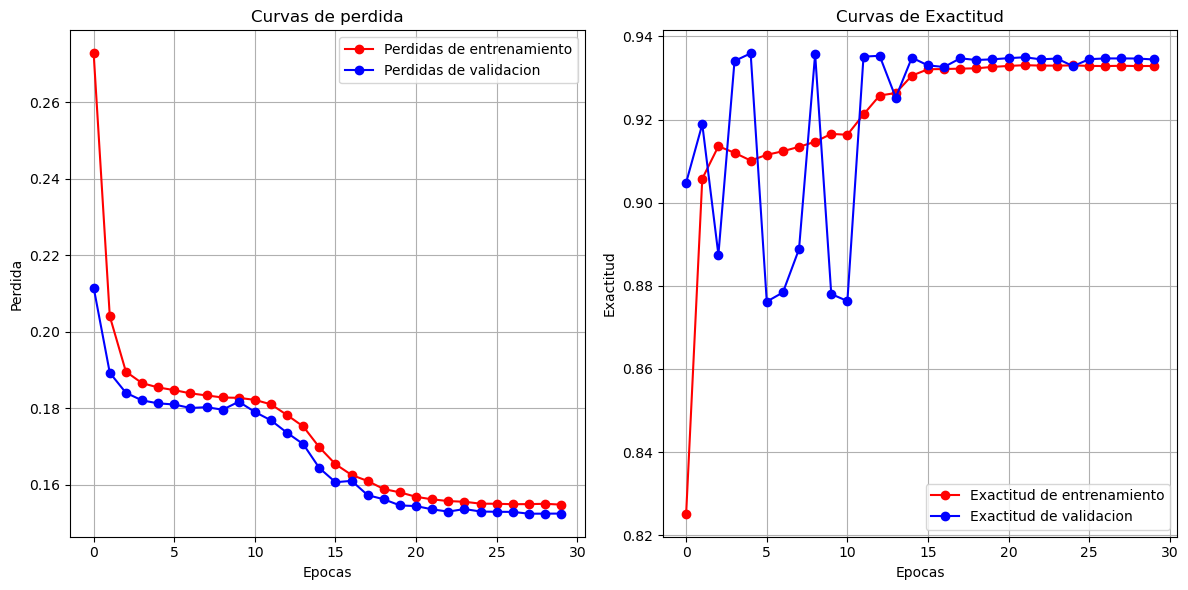

In [26]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
ax[0].plot(train_losses, 'o-', color='red',label='Perdidas de entrenamiento')
ax[0].plot(val_losses, 'o-', color='blue',label='Perdidas de validacion')
ax[0].set_xlabel('Epocas')
ax[0].set_ylabel('Perdida')
ax[0].set_title('Curvas de perdida')
ax[0].grid()
ax[0].legend()

ax[1].plot(train_accuracies, 'o-', color='red', label = 'Exactitud de entrenamiento')
ax[1].plot(val_accuracies, 'o-', color='blue',label = 'Exactitud de validacion')
ax[1].set_xlabel('Epocas')
ax[1].set_ylabel('Exactitud')
ax[1].set_title('Curvas de Exactitud')
ax[1].grid()
ax[1].legend()
plt.tight_layout()
plt.show()

### Ver datos

In [27]:
# Visualizar un lote de datos para ver que esta pasando
def ver_datos(dataloader, n=1):
    #n es el numero de grafos que quieres ver
    for i, data in enumerate(train_loader):
        print(f"Batch {i + 1}:")
        print(f"x (nodos): {data.x.shape}")
        print(f"edge_index (aristas): {data.edge_index.shape}")
        print(f"data.y.shape: {data.y.shape}")
        print(f"data.y.numpy: {data.y.numpy()}")
        
        # Imprimir nodos, aristas y atributos
        print(f"Nodos: {data.x[:]}")
        print(f"aristas: {data.edge_index[:, :]}")
        print(f" etiquetas de aristas: {data.y[:]}")
        
        if i == 0:
            break

### Validacion

DataBatch(x=[7, 2], edge_index=[0], y=[7], batch=[7], ptr=[3])
              precision    recall  f1-score   support

     Clase 0       1.00      0.93      0.96     23649
     Clase 1       0.88      0.99      0.93     12443

    accuracy                           0.95     36092
   macro avg       0.94      0.96      0.95     36092
weighted avg       0.96      0.95      0.95     36092



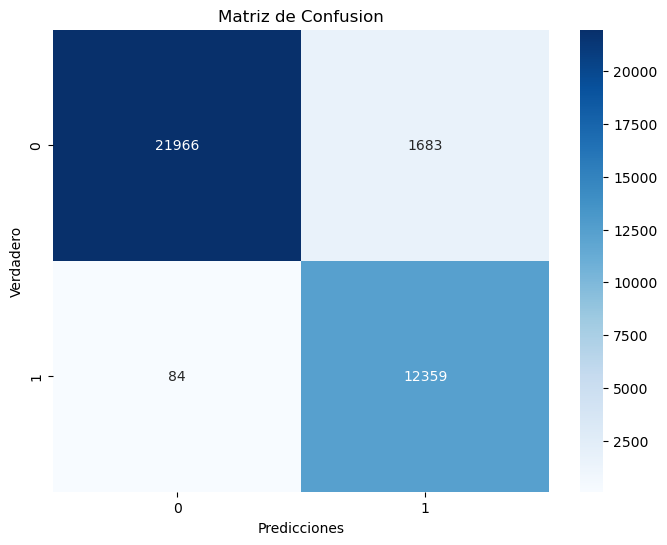

In [29]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar_modelo(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Desactivar gradientes
    with torch.no_grad():
        for data in dataloader:
            if data.edge_index.numel() == 0:
                print(data)  
                continue 
            data = data.to(device)
            logits = model(data.x, data.edge_index)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(data.y.cpu())
    
    # Concatenar predicciones y etiquetas reales
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    # Calcular matriz de confusion y el report
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, output_dict=True)
    print(classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"]))
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.title(f'Matriz de Confusion')
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.show()

evaluar_modelo(model, test_loader, device)

    
        

### ROC y AUC

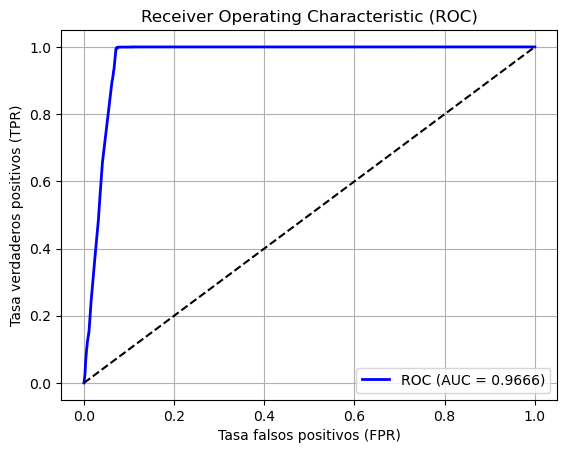

In [31]:
from sklearn.metrics import roc_curve, auc
def probs_labels(model, dataloader, device):
    all_probs = []  # Probabilidades para la clase positiva
    all_labels = []  # Etiquetas verdaderas

    model.eval()
    with torch.no_grad():
        for data in dataloader:
            if data.edge_index.numel() == 0:  
                continue 
            out = model(data.x, data.edge_index)
            probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()  # Probabilidades de la clase 1
            labels = data.y.cpu().numpy()

            all_probs.extend(probs.tolist()) 
            all_labels.extend(labels.tolist()) 
    return all_probs, all_labels

def roc_y_auc(all_probs, all_labels):
    FPR, TPR, _ = roc_curve(all_labels, all_probs) #tasa falsos positivos y tasa verdaderos positivos
    roc_auc = auc(FPR, TPR) #area bajo la ROC

    plt.figure()
    plt.plot(FPR, TPR, color ='b', lw=2, label = f'ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Línea diagonal
    plt.xlabel('Tasa falsos positivos (FPR)')
    plt.ylabel('Tasa verdaderos positivos (TPR)')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.grid()
    plt.legend()
    plt.show()

all_probs, all_labels = probs_labels(model, test_loader, device)
roc_y_auc(all_probs, all_labels)

### Curvas de precision recall

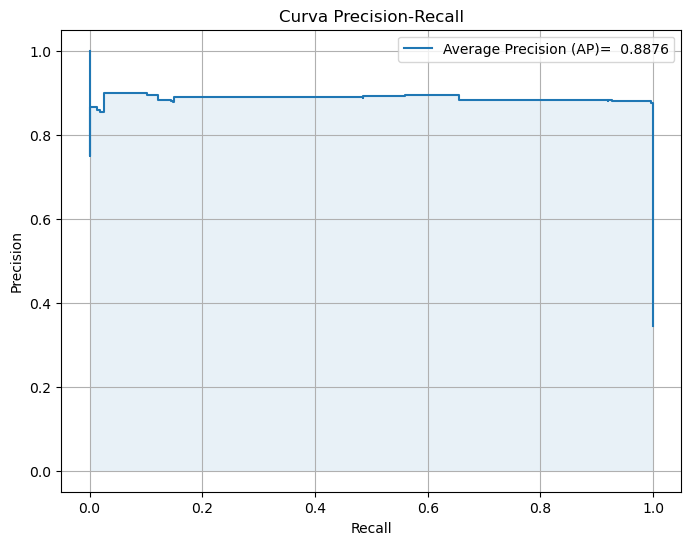

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def precision_recall(all_labels, all_probs):
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    average_precision = average_precision_score(all_labels, all_probs)

    plt.figure(figsize = (8,6))
    plt.step(recall, precision, where = 'post', label = f'Average Precision (AP)= {average_precision: .4f}')
    plt.fill_between(recall, precision, step='post', alpha = 0.1)
    plt.title('Curva Precision-Recall')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

precision_recall(all_labels,all_probs)